# Attention Matching Diagrams

This notebook recreates the Figure 4 style diagrams from cached results. By default it plots the top causal token-copying and concept-copying heads for `Llama-3.1-8B`, using:

- causal head rankings from `cache/head_orderings`
- causal copying scores from `cache/causal_scores`
- next-token matching scores from `cache/attention_scores/*_randomtokents.json`
- last-token matching scores from `cache/attention_scores/*.json`


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "serif",
    }
)

MODEL_NAME = "Llama-3.1-8B"
DISPLAY_NAME = MODEL_NAME
TOP_K = 16
CAUSAL_N = 1024
ATTENTION_N = 2048
SEQUENCE_LEN = 30
SAVE_FIGURE = False
FIGURE_NAME = f"{MODEL_NAME.lower().replace('.', '_')}_attention_matching.png"
ANNOTATE_MAX_LAST_TOKEN = True

In [ ]:
def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.append(candidate)
        candidates.append(candidate / "dual-route-induction")

    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
ROOT

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/dual-route-induction')

In [ ]:
def choose_existing_path(*paths: Path) -> Path:
    for path in paths:
        if path.exists():
            return path
    checked = "\n".join(str(path) for path in paths)
    raise FileNotFoundError(f"None of these paths exist:\n{checked}")


def ranking_path(score_type: str) -> Path:
    return choose_existing_path(
        ROOT / "cache" / "head_orderings" / MODEL_NAME / f"{score_type}_copying.json",
        ROOT
        / "cache"
        / "head_orderings"
        / MODEL_NAME
        / f"{score_type}_copying_len{SEQUENCE_LEN}_n{CAUSAL_N}.json",
    )


def causal_score_path(score_type: str) -> Path:
    return choose_existing_path(
        ROOT
        / "cache"
        / "causal_scores"
        / MODEL_NAME
        / f"{score_type}_copying_len{SEQUENCE_LEN}_n{CAUSAL_N}.json"
    )


def attention_score_path(random_tokens: bool) -> Path:
    suffix = "_randomtokents" if random_tokens else ""
    return choose_existing_path(
        ROOT
        / "cache"
        / "attention_scores"
        / MODEL_NAME
        / f"n{ATTENTION_N}_seqlen{SEQUENCE_LEN}{suffix}.json"
    )


def load_ranked_heads(path: Path) -> list[tuple[int, int]]:
    return [tuple(head) for head in json.loads(path.read_text())]


def load_scored_heads(path: Path) -> dict[tuple[int, int], float]:
    records = json.loads(path.read_text())
    return {(item["layer"], item["head_idx"]): float(item["score"]) for item in records}


def load_attention_metric(path: Path, key: str) -> dict[tuple[int, int], float]:
    records = json.loads(path.read_text())[key]
    return {(item["layer"], item["head_idx"]): float(item["score"]) for item in records}


def head_label(head: tuple[int, int]) -> str:
    return f"{head[0]}.{head[1]}"


NEXT_TOKEN_SCORES = load_attention_metric(
    attention_score_path(random_tokens=True), "next_tok_attn"
)
LAST_TOKEN_SCORES = load_attention_metric(
    attention_score_path(random_tokens=False), "end_tok_attn"
)

In [ ]:
def build_panel_table(score_type: str, top_k: int = TOP_K) -> pd.DataFrame:
    ranked_heads = load_ranked_heads(ranking_path(score_type))[:top_k]
    causal_scores = load_scored_heads(causal_score_path(score_type))

    rows = []
    for layer, head_idx in ranked_heads:
        key = (layer, head_idx)
        rows.append(
            {
                "head": head_label(key),
                "layer": layer,
                "head_idx": head_idx,
                "causal_copying_score": causal_scores[key],
                "next_token_matching": NEXT_TOKEN_SCORES[key],
                "last_token_matching": LAST_TOKEN_SCORES[key],
            }
        )

    return pd.DataFrame(rows)


token_heads = build_panel_table("token")
concept_heads = build_panel_table("concept")

display(token_heads.round(4))
display(concept_heads.round(4))

,head,layer,head_idx,causal_copying_score,next_token_matching,last_token_matching
0,15.30,15,30,0.0032,0.9807,0.0003
1,16.23,16,23,0.0020,0.6103,0.0016
2,31.24,31,24,0.0018,0.0031,0.0028
3,20.23,20,23,0.0010,0.2170,0.0246
4,15.28,15,28,0.0010,0.5339,0.0029
5,31.14,31,14,0.0008,0.0007,0.0013
6,29.21,29,21,0.0006,0.0767,0.0061
7,31.26,31,26,0.0005,0.0079,0.0080
8,15.1,15,1,0.0005,0.6902,0.0338
9,16.1,16,1,0.0004,0.4001,0.0610


,head,layer,head_idx,causal_copying_score,next_token_matching,last_token_matching
0,15.1,15,1,0.0004,0.6902,0.0338
1,21.1,21,1,0.0004,0.0820,0.1596
2,13.27,13,27,0.0003,0.1591,0.2193
3,27.20,27,20,0.0003,0.1561,0.0678
4,20.1,20,1,0.0003,0.5202,0.1395
5,9.27,9,27,0.0002,0.0876,0.1705
6,19.0,19,0,0.0002,0.1805,0.1116
7,15.16,15,16,0.0001,0.0271,0.0497
8,19.1,19,1,0.0001,0.0558,0.0805
9,15.17,15,17,0.0001,0.0340,0.0185


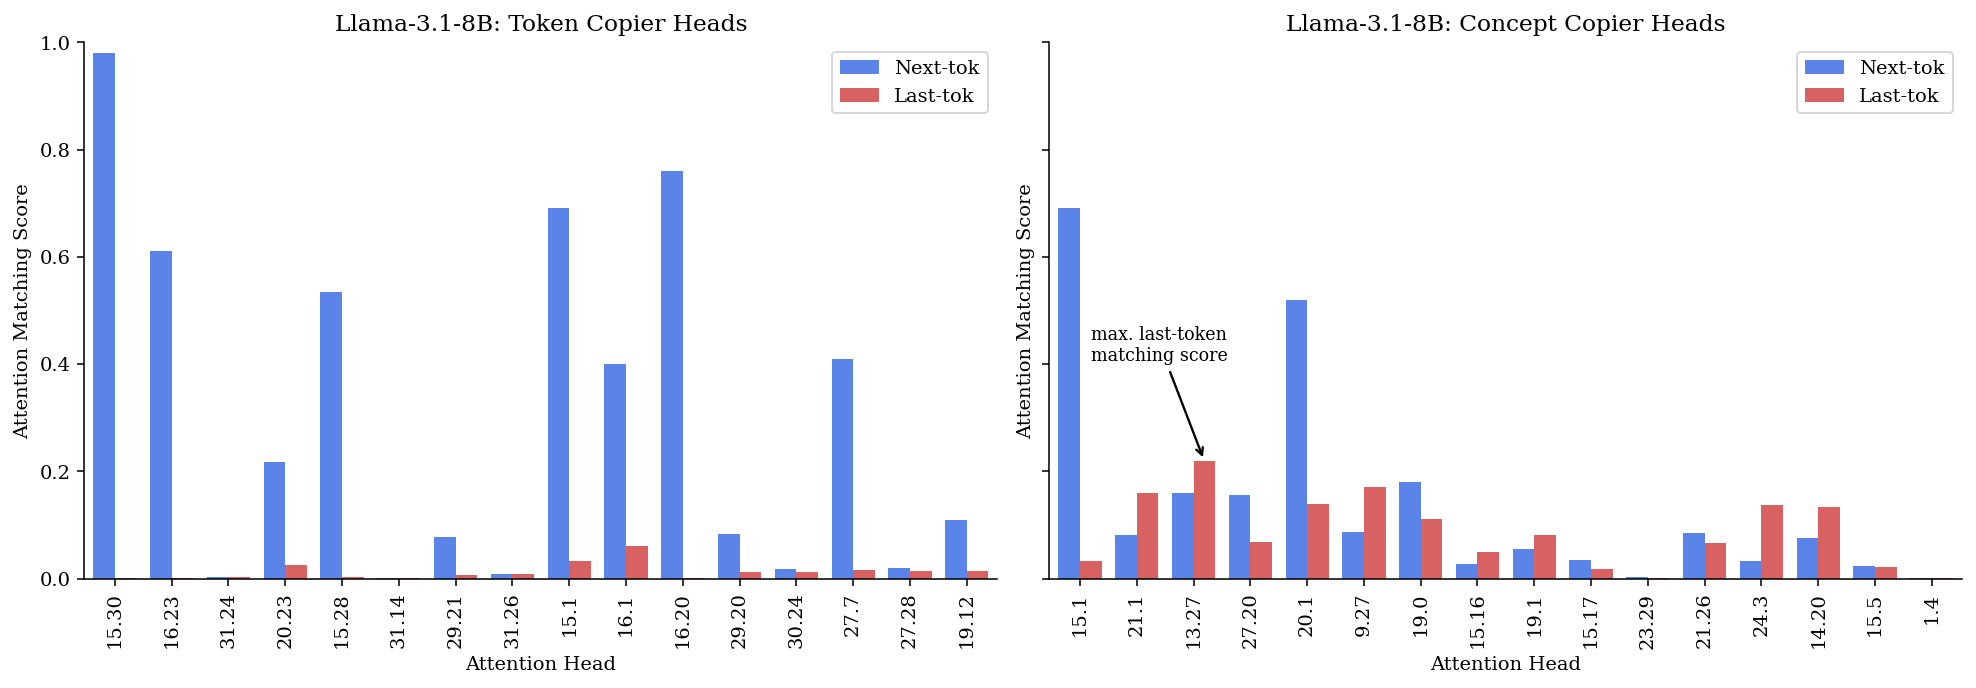

In [ ]:
PANEL_TITLES = {
    "token": "Token Copier Heads",
    "concept": "Concept Copier Heads",
}


def plot_panel(
    ax, df: pd.DataFrame, title: str, annotate_max_last_token: bool = False
) -> None:
    x = np.arange(len(df))
    width = 0.38

    ax.bar(
        x - width / 2,
        df["next_token_matching"],
        width=width,
        label="Next-tok",
        color="#5B84E8",
    )
    ax.bar(
        x + width / 2,
        df["last_token_matching"],
        width=width,
        label="Last-tok",
        color="#D86161",
    )

    ax.set_title(f"{DISPLAY_NAME}: {title}")
    ax.set_xlabel("Attention Head")
    ax.set_ylabel("Attention Matching Score")
    ax.set_xticks(x)
    ax.set_xticklabels(df["head"], rotation=90)
    ax.set_ylim(
        0,
        max(
            1.0,
            float(df[["next_token_matching", "last_token_matching"]].to_numpy().max())
            * 1.1,
        ),
    )
    ax.legend(loc="upper right")
    ax.margins(x=0.01)

    if annotate_max_last_token:
        max_idx = int(df["last_token_matching"].to_numpy().argmax())
        max_val = float(df["last_token_matching"].iloc[max_idx])
        text_x = max(0.2, max_idx - 2.2)
        text_y = min(ax.get_ylim()[1] * 0.88, max_val + 0.18)
        ax.annotate(
            "max. last-token\nmatching score",
            xy=(x[max_idx] + width / 2, max_val),
            xytext=(text_x, text_y),
            arrowprops={"arrowstyle": "->", "lw": 1.2},
            fontsize=9,
            ha="left",
            va="bottom",
        )


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True, constrained_layout=True)

plot_panel(axes[0], token_heads, PANEL_TITLES["token"])
plot_panel(
    axes[1],
    concept_heads,
    PANEL_TITLES["concept"],
    annotate_max_last_token=ANNOTATE_MAX_LAST_TOKEN,
)

if SAVE_FIGURE:
    output_dir = ROOT / "figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / FIGURE_NAME
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {output_path}")

plt.show()